# Valutazione file iniziale

## IMPORT

In [ ]:
from dl_client import DatalakeClient
import pandas as pd

# Initialize the DatalakeClient
client = DatalakeClient()

# Search files related to the "PLASMA_ABETA_PROJECT_QUANTERIX"
search = client.query_files(query={'custom.level': 'raw', 'custom.file_code': ['PLASMA_ABETA_PROJECT_ADX_VUMC','PLASMA_ABETA_PROJECT_QUANTERIX', 'PLASMA_ABETA_PROJECT_ROCHE', 'PLASMA_ABETA_PROJECT_SHIMADZU', 'PLASMA_ABETA_PROJECT_U_OF_GOTHENBURG','PLASMA_ABETA_PROJECT_WASH_U']})

# Get the filenames from the search result
files = [x['filename'] for x in search['included_files']]
print(len(files))  # Print the number of files found

# Download and extract the files from the data lake
zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

# List to store DataFrames
dfs = []

# Process each file
for file_name in zip_files.keys():
    print(f"Processing file: {file_name}")
    
    # Load the dataset for this file
    dataset = zip_files[file_name]
    
    # Make a copy of the dataset for processing
    df_new = dataset.copy(deep=True)
    
    # Add a new column for the method based on the file name
    # You can adjust this line based on how the method is encoded in the file name
    df_new['Method'] = file_name.split("/")[-1].split(".")[0]  # Extract method name from the file name
    
    # Append the dataset to the list of DataFrames
    dfs.append(df_new)

# Combine all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)

# Check for duplicates based on 'RID' and 'EXAMDATE' across different methods
duplicate_rids = combined_df.groupby(['RID', 'EXAMDATE']).size().reset_index(name='count')

# Filter for RID-EXAMDATE pairs that appear more than once (i.e., duplicates)
duplicate_rids = duplicate_rids[duplicate_rids['count'] > 1]

# Merge the duplicate RID-EXAMDATE pairs with the original data to identify which methods they appear in
duplicates_details = pd.merge(combined_df, duplicate_rids[['RID', 'EXAMDATE']], on=['RID', 'EXAMDATE'])

# Show the rows with duplicate RID-EXAMDATE across different methods
print(duplicates_details)

# Optionally, save the result to a CSV for further inspection
duplicates_details.to_csv('duplicates_rid_examdate.csv', index=False)




In [18]:
from dl_client import DatalakeClient
import pandas as pd

client = DatalakeClient()

## Ricerca file

In [26]:
search = client.query_files(query={'custom.level': 'raw', 'custom.file_code': ['UCBERKELEY_TAUPVC_6MM']})
files = [x['filename'] for x in search['included_files']]
print(len(files))# Print the number of files found

1


In [27]:
print(files)

['UCBERKELEY_TAUPVC_6MM_28Oct2025.csv']


## Download zip file trovati

In [28]:
zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

## Apertura singoli file

In [29]:
file_name = list(zip_files.keys())[0]
print(file_name)
dataset = zip_files[file_name]

df_new = dataset.copy(deep=True)
df_new.head()

UCBERKELEY_TAUPVC_6MM_28Oct2025.csv


,LONIUID,PTID,RID,VISCODE,VISCODE2,SCANDATE,SITEID,PROCESSDATE,TRACER,TRACER_SUVR_WARNING,...,RIGHT_PALLIDUM_VOLUME,RIGHT_PUTAMEN_SUVR,RIGHT_PUTAMEN_VOLUME,RIGHT_THALAMUS_PROPER_SUVR,RIGHT_THALAMUS_PROPER_VOLUME,RIGHT_VENTRALDC_SUVR,RIGHT_VENTRALDC_VOLUME,RIGHT_VESSEL_SUVR,RIGHT_VESSEL_VOLUME,update_stamp
0,1594604,011_S_0021,21,init,m144,2018-02-02,11,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,...,1623.0,1.593,4225.0,1.234,5781.0,1.651,3422.0,NaN,14.0,2025-09-12 20:31:38.0
1,1596177,023_S_0031,31,init,m150,2018-04-24,23,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,...,2126.0,1.648,5712.0,1.219,6261.0,1.712,2959.0,NaN,6.0,2025-09-12 20:31:38.0
2,1596172,023_S_0031,31,y1,m162,2019-04-23,23,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,...,2156.0,1.496,5967.0,1.112,5947.0,1.538,3008.0,NaN,8.0,2025-09-12 20:31:38.0
3,1598898,067_S_0056,56,init,m144,2018-02-20,67,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,...,1551.0,2.066,4024.0,1.477,6595.0,1.710,3646.0,NaN,42.0,2025-09-12 20:31:38.0
4,1598985,067_S_0056,56,y1,m156,2019-01-10,67,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,...,1671.0,1.904,4155.0,1.482,6386.0,1.736,3681.0,NaN,39.0,2025-09-12 20:31:38.0


In [33]:
df_new.keys()

Index(['LONIUID', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'SITEID',
       'PROCESSDATE', 'TRACER', 'TRACER_SUVR_WARNING',
       ...
       'RIGHT_PALLIDUM_VOLUME', 'RIGHT_PUTAMEN_SUVR', 'RIGHT_PUTAMEN_VOLUME',
       'RIGHT_THALAMUS_PROPER_SUVR', 'RIGHT_THALAMUS_PROPER_VOLUME',
       'RIGHT_VENTRALDC_SUVR', 'RIGHT_VENTRALDC_VOLUME', 'RIGHT_VESSEL_SUVR',
       'RIGHT_VESSEL_VOLUME', 'update_stamp'],
      dtype='object', length=335)

In [34]:
print(list(df_new.columns))


['LONIUID', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'SITEID', 'PROCESSDATE', 'TRACER', 'TRACER_SUVR_WARNING', 'META_TEMPORAL_SUVR', 'META_TEMPORAL_VOLUME', 'CTX_ENTORHINAL_SUVR', 'CTX_ENTORHINAL_VOLUME', 'INFERIORCEREBELLUM_SUVR', 'INFERIORCEREBELLUM_VOLUME', 'CEREBRAL_WHITE_MATTER_SUVR', 'CEREBRAL_WHITE_MATTER_VOLUME', 'BRAINSTEM_SUVR', 'BRAINSTEM_VOLUME', 'CC_ANTERIOR_SUVR', 'CC_ANTERIOR_VOLUME', 'CC_CENTRAL_SUVR', 'CC_CENTRAL_VOLUME', 'CC_MID_ANTERIOR_SUVR', 'CC_MID_ANTERIOR_VOLUME', 'CC_MID_POSTERIOR_SUVR', 'CC_MID_POSTERIOR_VOLUME', 'CC_POSTERIOR_SUVR', 'CC_POSTERIOR_VOLUME', 'CSF_SUVR', 'CSF_VOLUME', 'VENTRICLE_3RD_SUVR', 'VENTRICLE_3RD_VOLUME', 'VENTRICLE_4TH_SUVR', 'VENTRICLE_4TH_VOLUME', 'VENTRICLE_5TH_SUVR', 'VENTRICLE_5TH_VOLUME', 'WM_HYPOINTENSITIES_SUVR', 'WM_HYPOINTENSITIES_VOLUME', 'NON_WM_HYPOINTENSITIES_SUVR', 'NON_WM_HYPOINTENSITIES_VOLUME', 'CTX_BANKSSTS_SUVR', 'CTX_BANKSSTS_VOLUME', 'CTX_CAUDALANTERIORCINGULATE_SUVR', 'CTX_CAUDALANTERIORCINGULATE_VOLUME', 

In [32]:
pd.Series(df_new.columns).to_clipboard(index=False)

In [ ]:
df_new['POOL'].unique()

## conto soggetti e soggetti con 2+ visits

In [24]:
tot_sub = len(df_new['RID'].unique())
print('totale subject:', tot_sub)
multiple_visists = (df_new['RID'].value_counts() > 1).sum()
print('subjects with multiple visits: ', multiple_visists)

totale subject: 121
subjects with multiple visits:  9


In [27]:
df_new

,RID,VISCODE,VISCODE2,EXAMDATE,GUSPECID,VID,DER,DRAWTIME,RUN,SEQ,NF_LIGHT,ABETA42,ABETA40,GFAP,update_stamp
0,31,v41,m120,2016-01-27,AA80GLLT-04,14,PLA,09:16:00,1,2,48.7,7.2,168.3,145.0,2021-05-25 13:34:58.0
1,138,v41,m120,2016-02-18,GA80GN4N-04,11,PLA,11:30:00,1,9,49.3,9.3,173.6,142.6,2021-05-25 13:34:58.0
2,150,v51,m120,2016-03-16,AA80GQ2W-03,14,PLA,10:00:00,1,16,27.8,5.9,125.8,114.1,2021-05-25 13:34:58.0
3,214,v41,m120,2016-03-29,HA80GQ5R-03,14,PLA,09:30:00,1,17,28.9,6.9,124.1,107.1,2021-05-25 13:34:58.0
4,303,init,m132,2017-04-12,DA80J8B7-03,0,PLA,10:31:00,1,116,36.9,9.2,200.2,167.4,2021-05-25 13:34:58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,5193,v41,m48,2017-06-12,FA80JJ1L-03,0,PLA,NaN,1,99,62.2,10.4,216.0,151.5,2021-05-25 13:34:58.0
126,5194,init,m48,2017-07-25,GA80JNZT-03,0,PLA,14:31:00,1,93,19.2,10.4,221.2,146.4,2021-05-25 13:34:58.0
127,5200,v41,m48,2017-07-12,DA80JLWC-04,0,PLA,10:02:00,1,91,36.3,11.6,299.8,171.3,2021-05-25 13:34:58.0
128,5236,init,m48,2017-07-27,AA80JNRW-03,0,PLA,11:23:00,1,92,54.6,7.8,227.0,174.9,2021-05-25 13:34:58.0


## range alcune variabili

In [ ]:
var_interesse = ['ENTORHINAL_SUVR', 'INFERIOR_TEMPORAL_SUVR', 'TAU_METAROI']   #Standardized Uptake Value Ratio = SUVR
df_interesse= df_new[var_interesse]
df_interesse.head()

,STATUS,MODALITY,TAU_METAROI
0,Complete,Flortaucipir,1.2242
1,Complete,Flortaucipir,1.1242
2,Complete,Flortaucipir,1.1468
3,Complete,Flortaucipir,1.3032
4,Complete,Flortaucipir,1.2984


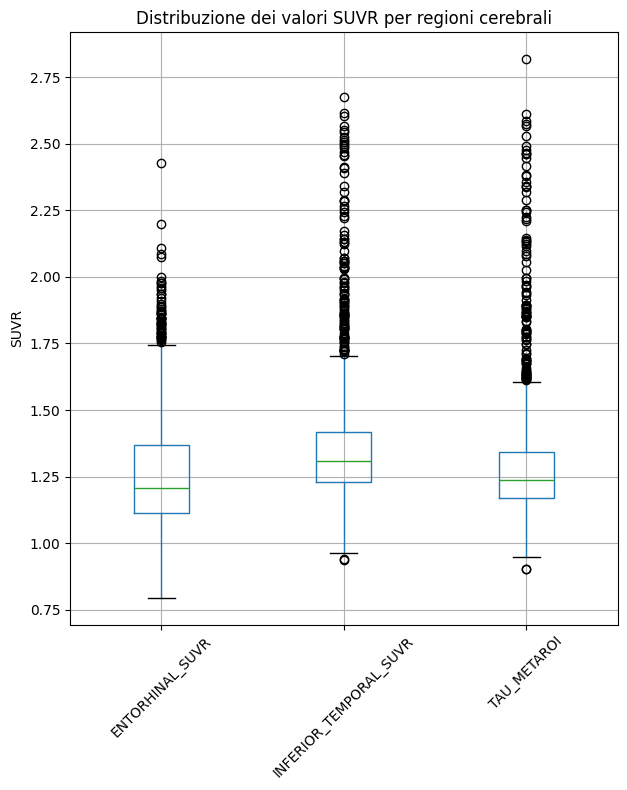

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione del plot
plt.figure(figsize=(12, 8))

# Box plot per le percentuali ICV



plt.subplot(1, 2, 2)
df_interesse.boxplot(rot=45)
plt.title('Distribuzione dei valori SUVR per regioni cerebrali')
plt.ylabel('SUVR')

plt.tight_layout()
plt.show()

In [36]:
# Calcolo del 1° e 99° percentile per ciascun volume ICV
print("=== 1° E 99° PERCENTILE  ===")
print()

percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=var_interesse, columns=['1° percentile', '99° percentile'])
for var in  var_interesse:
    percentile_df.loc[var, '1° percentile'] = df_interesse[var].quantile(0.01)
    percentile_df.loc[var, '99° percentile'] = df_interesse[var].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== 1° E 99° PERCENTILE  ===

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
ENTORHINAL_SUVR,0.899392,1.94356
INFERIOR_TEMPORAL_SUVR,1.012016,2.474596
TAU_METAROI,0.987448,2.429056


#  Check metadata di tutti i file uno per uno

In [ ]:
i =9

In [21]:
file_name = 'UPENNBIOMKADNIDIAN2017_09Oct2025.csv' #files[0]
print(file_name, '----------')
metadata = client.get_metadata(object_name='raw/'+file_name)
display(metadata['metadata']['custom'])
i += 1

UPENNBIOMKADNIDIAN2017_09Oct2025.csv ----------


{'download_type': 'study_files',
 'file_code': 'UPENNBIOMK_ADNIDIAN_ES_2017',
 'level': 'raw',
 'population': ['1', 'GO', '2'],
 'source': 'ADNI'}

NameError: name 'i' is not defined

In [31]:
zip_files = client.download_file(object_name='raw/'+file_name,  
    extract_zip=True
)

In [4]:
file_code = 'ADNIMERGE'
search = client.query_files(
    query={
        'custom.level' : 'cleaned_01',
        'custom.file_code': file_code
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)


In [15]:
file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]
zip_files

,RID,VISCODE,EXAMDATE,VERSION,IMAGE_UID,RUNDATE,STATUS,CBICA_ID,DATE,R702,...,R199,R200,R201,R202,R203,R204,R205,R206,R207,update_stamp
0,2,sc,2005-08-26,2016-03-21,I35475,2016-03-21,COMPLETE,011_S_0002_2005-08-26,2005-08-26,1784710,...,12577.70,7531.16,6862.94,8957.96,9767.36,3077.59,2563.72,1338.330,1044.690,2016-06-02 09:02:36.0
1,3,sc,2005-09-01,2016-03-21,I32237,2016-03-21,COMPLETE,011_S_0003_2005-09-01,2005-09-01,1785950,...,9596.26,6754.81,5647.18,8133.22,7992.18,3008.82,3520.32,1148.990,1203.530,2016-06-02 09:02:36.0
2,4,sc,2005-09-22,2016-03-21,I64631,2016-03-21,COMPLETE,022_S_0004_2005-09-22,2005-09-22,1619320,...,10444.50,7522.30,7652.39,8225.52,8943.81,2867.52,2141.69,1515.770,1755.200,2016-06-02 09:02:36.0
3,5,sc,2005-09-02,2016-03-21,I32246,2016-03-21,COMPLETE,011_S_0005_2005-09-02,2005-09-02,1655680,...,10243.40,5616.39,5902.29,8467.85,7683.51,2973.72,2405.68,1724.790,1643.910,2016-06-02 09:02:36.0
4,6,sc,2005-11-15,2016-03-21,I33025,2016-03-21,COMPLETE,100_S_0006_2005-11-15,2005-11-15,1528520,...,8364.14,5948.50,6253.38,5931.44,6659.54,2321.83,2245.08,1261.120,1250.460,2016-06-02 09:02:36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,1425,sc,2007-08-06,2016-03-21,I73357,2016-03-21,COMPLETE,041_S_1425_2007-08-06,2007-08-06,1360100,...,8223.08,6073.44,5872.55,6751.18,5906.35,3112.75,2164.66,1128.330,758.475,2016-06-02 09:02:38.0
836,1426,sc,2007-09-07,2016-03-21,I79102,2016-03-21,COMPLETE,137_S_1426_2007-09-07,2007-09-07,1612220,...,9022.20,5939.80,5302.83,6758.46,6978.18,1661.62,1788.38,944.368,1373.240,2016-06-02 09:02:38.0
837,1427,sc,2007-08-20,2016-03-21,I91126,2016-03-21,COMPLETE,127_S_1427_2007-08-20,2007-08-20,1552590,...,11428.10,6699.74,7530.97,9881.35,8473.67,3730.45,3510.70,1384.320,1608.320,2016-06-02 09:02:38.0
838,1430,sc,2007-09-07,2016-03-21,I79857,2016-03-21,COMPLETE,128_S_1430_2007-09-07,2007-09-07,1203100,...,7840.67,5337.89,5426.14,6072.02,6321.73,1960.17,1864.41,544.491,910.615,2016-06-02 09:02:38.0


In [ ]:

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

In [3]:
print(zip_files.keys())

dict_keys(['ADNIMERGE_06Jun2025.csv', 'MMSE_06Jun2025.csv', 'PTDEMOG_06Jun2025.csv', 'ADSP_PHC_BIOMARKER_06Jun2025.csv', 'BLCHANGE_06Jun2025.csv', 'DXSUM_06Jun2025.csv'])


In [14]:
file_name = 'ADNIMERGE_06Jun2025.csv'
df = zip_files[file_name]

NameError: name 'zip_files' is not defined

In [21]:
metadata = client.get_metadata(
            object_name = 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf'
        )
print(metadata['metadata'])

{'_id': '6838828ff99891d54bb44883', 'bucket_name': 'aind', 'content_type': 'application/pdf', 'created_at': '2025-05-29T15:51:43.525784', 'custom': {'author': 'Biel', 'keywords': ['ADNI', 'preclin', 'MCI', 'AD', 'imaging', 'Braak', 'staging', 'cogn', 'longit', 'predict'], 'year': '2021'}, 'filename': 'Biel_2021_ADNI_preclin_MCI_AD_imaging_Braak_staging_cogn_longit_predict.pdf', 'last_modified': '2025-05-29T15:51:43.443935', 'object_name': 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 'path': '/data/aind/articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 's3_url': 'http://131.175.204.159:9000/aind/articles/Biel%202021%20ADNI%20preclin%20MCI%20AD%20imaging%20Braak%20staging%20cogn%20longit%20predict.pdf?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=admin%2F20250529%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20250529T155143Z&X-Amz-Expires=3600&X-Amz-SignedHeaders=host&X-Amz-Signature=9d7b5fec764c2b503c460b66

In [6]:
df

,PTID,RID,COHORT,VISCODE,EXAMDATE,AGE,GENDER,EDUCAT,ETHNICITY,RACE,...,FAQ,MOCA,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,ICV,DX,AGE_bl
0,011_S_0002,2,ADNI1,0,2005-09-08,74.3,1,16,0.0,5.0,...,0.0,NaN,118233.0,8336.0,4177.0,16559.0,27936.0,1984660.0,0,74.3
1,011_S_0003,3,ADNI1,0,2005-09-12,81.3,1,18,0.0,5.0,...,10.0,NaN,84599.0,5319.0,1791.0,15506.0,18422.0,1920690.0,3,81.3
2,011_S_0003,3,ADNI1,6,2006-03-13,81.8,1,18,0.0,5.0,...,12.0,NaN,88580.0,5446.0,2427.0,14400.0,16972.0,1906430.0,3,81.3
3,011_S_0003,3,ADNI1,12,2006-09-12,82.3,1,18,0.0,5.0,...,17.0,NaN,90099.0,5157.0,1596.0,14617.0,17330.0,1903820.0,3,81.3
4,011_S_0003,3,ADNI1,24,2007-09-12,83.3,1,18,0.0,5.0,...,14.0,NaN,97420.0,5139.0,1175.0,14033.0,16398.0,1903420.0,3,81.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11453,168_S_6180,6180,ADNI3,66,2023-07-25,92.0,1,16,0.0,5.0,...,7.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,1,86.8
11454,135_S_6446,6446,ADNI3,60,2023-07-12,66.5,1,12,0.0,5.0,...,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,1,61.5
11455,041_S_6731,6731,ADNI3,48,2023-07-31,70.9,0,20,0.0,5.0,...,7.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3,66.8
11456,035_S_6480,6480,ADNI3,60,2023-07-27,84.9,0,16,0.0,5.0,...,2.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,1,79.9
